# Embedding Visualization

Load and visualize encoder embeddings extracted from hBehaveMAE.
Analysis is done **per-stage** (not concatenated).

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import os
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("UMAP not installed. Run: uv add umap-learn")

## 1. Load All Videos

In [2]:
import h5py
import numpy as np
from pathlib import Path

# Safely determine BASE_DIR whether in a script or a Jupyter Notebook
try:
    BASE_DIR = Path(__file__).resolve().parent.parent
except NameError:
    BASE_DIR = Path.cwd()
    if BASE_DIR.name == "notebooks":
        BASE_DIR = BASE_DIR.parent

# Point to your consolidated H5 embeddings file
EMB_H5_PATH = BASE_DIR / "data/embeddings/ofd_tailhip_20260226-205043.h5"

# Initialize lists
all_stage1 = []
all_stage2 = []
all_stage3 = []
video_names = []
video_boundaries = [0]  # frame indices where each video starts

print(f"Loading embeddings from {EMB_H5_PATH}...")

with h5py.File(EMB_H5_PATH, 'r') as f:
    available_videos = list(f.keys())
    print(f"Found {len(available_videos)} videos in H5 file")
    
    for vid in available_videos:
        # Ensure all stages exist before attempting to load
        if all(stage in f[vid] for stage in ["stage1", "stage2", "stage3"]):
            s1 = f[vid]["stage1"][:]
            s2 = f[vid]["stage2"][:]
            s3 = f[vid]["stage3"][:]
            
            all_stage1.append(s1)
            all_stage2.append(s2)
            all_stage3.append(s3)
            
            video_names.append(vid)
            # Use the length of stage1 to increment the boundary
            video_boundaries.append(video_boundaries[-1] + len(s1))
        else:
            print(f"  -> Skipping {vid}: Missing one or more stages.")

# Concatenate all videos into massive arrays
stage1 = np.concatenate(all_stage1, axis=0)
stage2 = np.concatenate(all_stage2, axis=0)
stage3 = np.concatenate(all_stage3, axis=0)

print(f"\nLoaded {len(video_names)} valid videos")
print(f"Stage 1: {stage1.shape}")
print(f"Stage 2: {stage2.shape}")
print(f"Stage 3: {stage3.shape}")
print(f"Total frames: {stage1.shape[0]}")

Loading embeddings from /scratch/michal/projects/dvc_ofd_2025/code/BehaveMAE_reconstruction/extract_embeding_folder_kptmsq/data/embeddings/ofd_tailhip_20260226-205043.h5...
Found 3224 videos in H5 file

Loaded 3224 valid videos
Stage 1: (56332088, 128)
Stage 2: (56332088, 192)
Stage 3: (56332088, 256)
Total frames: 56332088


In [4]:
# Create video ID per frame (for coloring)
video_ids = np.zeros(stage1.shape[0], dtype=int)
for i, (start, end) in enumerate(zip(video_boundaries[:-1], video_boundaries[1:])):
    video_ids[start:end] = i

print(f"Video ID range: {video_ids.min()} - {video_ids.max()}")

Video ID range: 0 - 199


## 2. Per-Stage Standardization

In [5]:
# Standardize each stage separately
scaler1 = StandardScaler()
scaler2 = StandardScaler()
scaler3 = StandardScaler()

stage1_scaled = scaler1.fit_transform(stage1)
stage2_scaled = scaler2.fit_transform(stage2)
stage3_scaled = scaler3.fit_transform(stage3)

stages = {
    "Stage 1": stage1_scaled,
    "Stage 2": stage2_scaled,
    "Stage 3": stage3_scaled,
}

## 3. Heatmaps (Single Video Example)

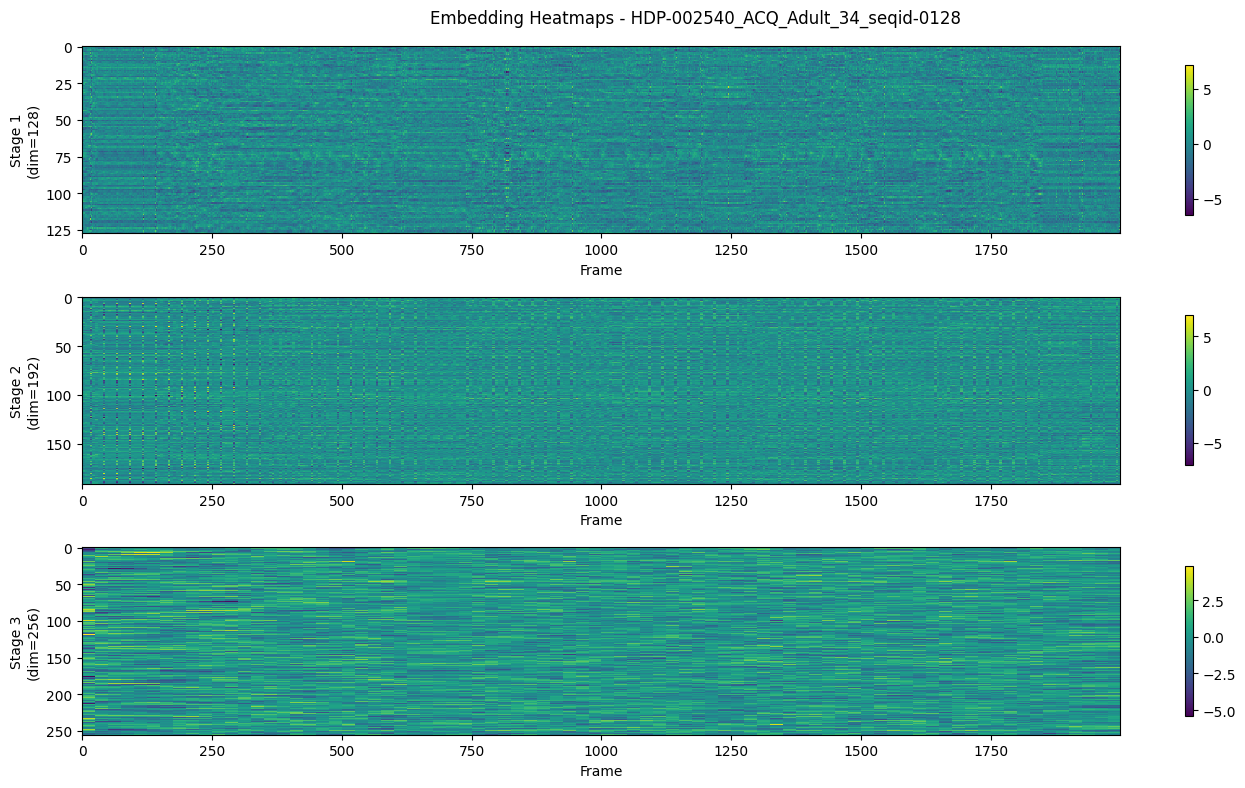

In [6]:
# Show heatmap for first video
vid_idx = 0
start, end = video_boundaries[vid_idx], video_boundaries[vid_idx + 1]
T_vis = min(2000, end - start)

fig, axes = plt.subplots(3, 1, figsize=(14, 8))

for ax, (name, emb) in zip(axes, [("Stage 1", stage1_scaled), ("Stage 2", stage2_scaled), ("Stage 3", stage3_scaled)]):
    im = ax.imshow(emb[start:start+T_vis].T, aspect="auto", cmap="viridis", interpolation="nearest")
    ax.set_ylabel(f"{name}\n(dim={emb.shape[1]})")
    ax.set_xlabel("Frame")
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle(f"Embedding Heatmaps - {video_names[vid_idx]}", fontsize=12)
plt.tight_layout()
plt.show()

## 4. PCA Per Stage

In [7]:
# PCA for each stage
n_components = 50

pca1 = PCA(n_components=n_components)
pca2 = PCA(n_components=n_components)
pca3 = PCA(n_components=n_components)

pca1_result = pca1.fit_transform(stage1_scaled)
pca2_result = pca2.fit_transform(stage2_scaled)
pca3_result = pca3.fit_transform(stage3_scaled)

pca_results = {
    "Stage 1": (pca1, pca1_result),
    "Stage 2": (pca2, pca2_result),
    "Stage 3": (pca3, pca3_result),
}

for name, (pca, _) in pca_results.items():
    print(f"{name}: {np.cumsum(pca.explained_variance_ratio_[:10])[-1]:.1%} variance in 10 PCs")

Stage 1: 56.1% variance in 10 PCs
Stage 2: 62.1% variance in 10 PCs
Stage 3: 57.6% variance in 10 PCs


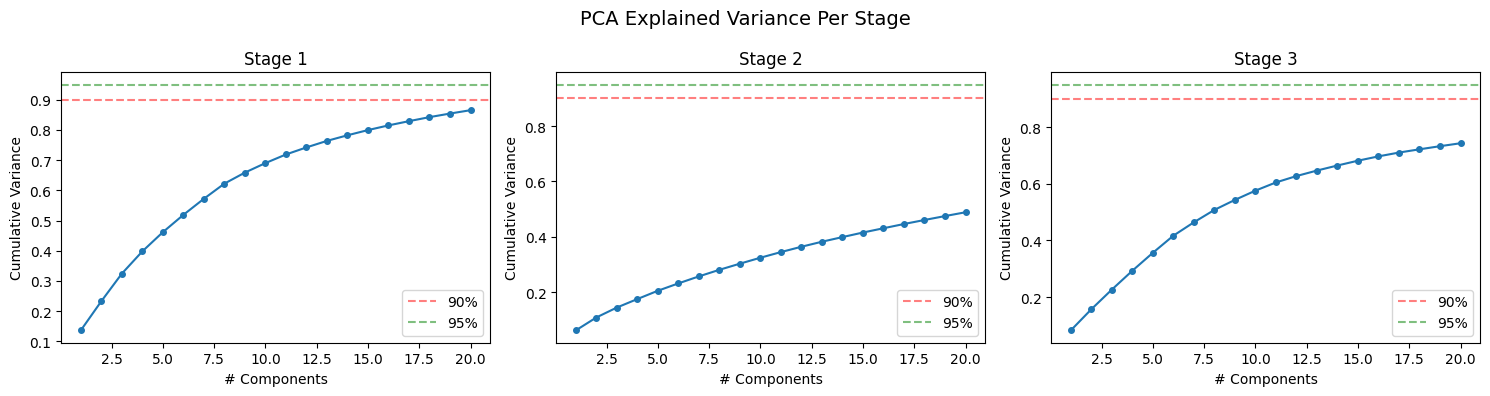

: 

In [ ]:
# Explained variance per stage
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, (pca, _)) in zip(axes, pca_results.items()):
    ax.plot(range(1, 21), np.cumsum(pca.explained_variance_ratio_[:20]), marker='o', markersize=4)
    ax.axhline(0.9, color='r', linestyle='--', alpha=0.5, label='90%')
    ax.axhline(0.95, color='g', linestyle='--', alpha=0.5, label='95%')
    ax.set_xlabel("# Components")
    ax.set_ylabel("Cumulative Variance")
    ax.set_title(name)
    ax.legend()

plt.suptitle("PCA Explained Variance Per Stage", fontsize=14)
plt.tight_layout()
plt.show()

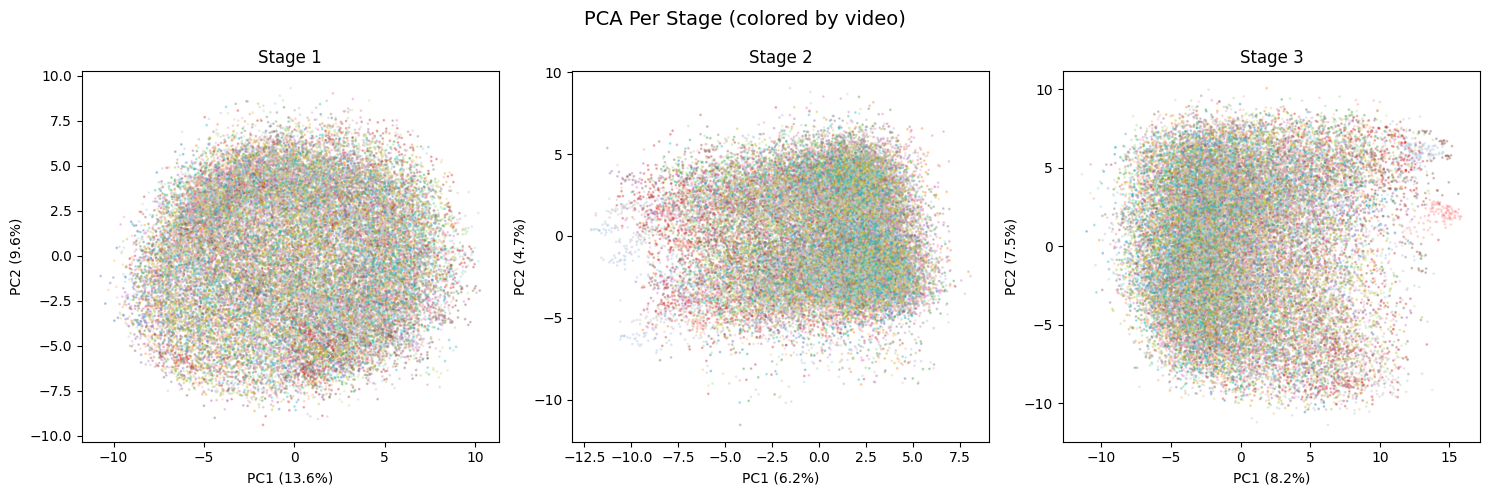

: 

In [ ]:
# PCA 2D scatter per stage (colored by video)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Subsample for plotting
subsample = 10
idx = np.arange(0, stage1.shape[0], subsample)

for ax, (name, (pca, pca_res)) in zip(axes, pca_results.items()):
    scatter = ax.scatter(
        pca_res[idx, 0], pca_res[idx, 1], 
        c=video_ids[idx], cmap='tab20', s=1, alpha=0.3
    )
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    ax.set_title(name)

plt.suptitle("PCA Per Stage (colored by video)", fontsize=14)
plt.tight_layout()
plt.show()

## 5. K-Means Clustering Per Stage

In [11]:
# Subsample for clustering (2.9M is too many)
cluster_subsample = 100  # use every 100th frame
cluster_idx = np.arange(0, stage1.shape[0], cluster_subsample)
print(f"Clustering on {len(cluster_idx)} samples (subsampled from {stage1.shape[0]})")

stage1_for_cluster = stage1_scaled[cluster_idx]
stage2_for_cluster = stage2_scaled[cluster_idx]
stage3_for_cluster = stage3_scaled[cluster_idx]

# Cluster each stage separately (on subsampled data)
n_clusters = 15

kmeans1 = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans2 = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans3 = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

# Fit on subsampled data
kmeans1.fit(stage1_for_cluster)
kmeans2.fit(stage2_for_cluster)
kmeans3.fit(stage3_for_cluster)

# Predict on ALL data
# labels1 = kmeans1.predict(stage1_scaled)
# Only get labels for the subsampled points used in visualization
labels1_sub = kmeans1.predict(stage1_for_cluster)  # Only 3307 samples
labels2_sub = kmeans2.predict(stage2_for_cluster)
labels3_sub = kmeans3.predict(stage3_for_cluster)
# Use cluster_idx to map back when needed

# labels2 = kmeans2.predict(stage2_scaled)
# labels3 = kmeans3.predict(stage3_scaled)

Clustering on 33065 samples (subsampled from 3306437)


OpenBLAS warning: precompiled NUM_THREADS exceeded, adding auxiliary array for thread metadata.
To avoid this warning, please rebuild your copy of OpenBLAS with a larger NUM_THREADS setting
or set the environment variable OPENBLAS_NUM_THREADS to 64 or lower


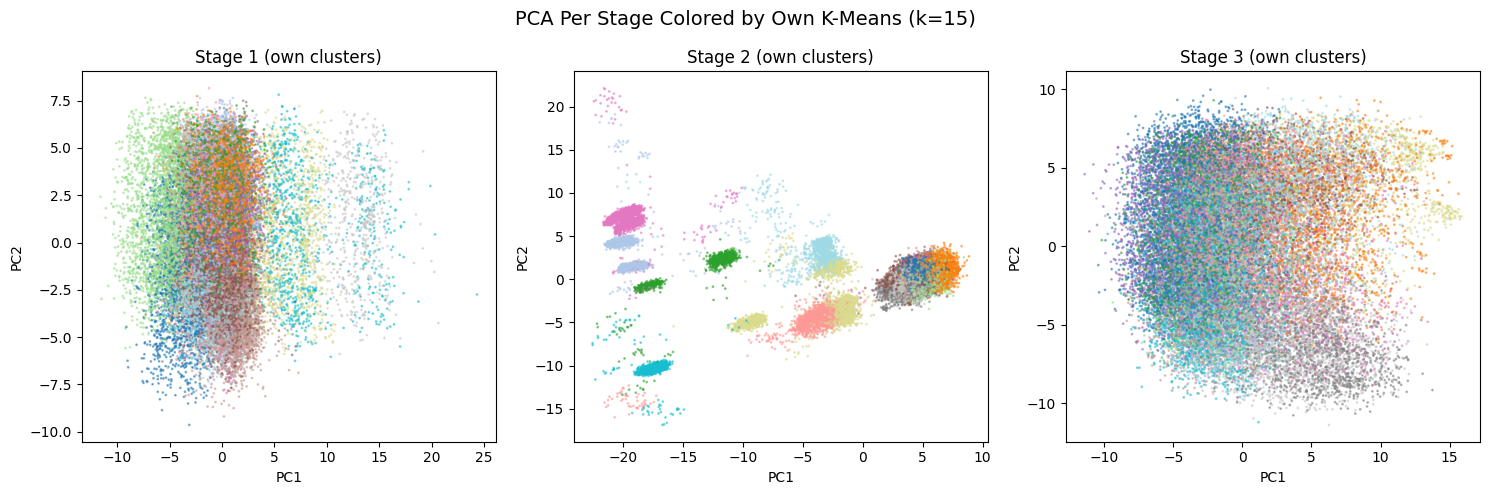

In [12]:
# PCA per stage colored by own clusters
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, (pca, pca_res)), labels_sub in zip(axes, pca_results.items(), [labels1_sub, labels2_sub, labels3_sub]):
    scatter = ax.scatter(
        pca_res[cluster_idx, 0], pca_res[cluster_idx, 1],  # Use cluster_idx, not idx
        c=labels_sub, cmap='tab20', s=1, alpha=0.5  # labels_sub already has correct length
    )
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(f"{name} (own clusters)")

plt.suptitle(f"PCA Per Stage Colored by Own K-Means (k={n_clusters})", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Cross-Stage Clustering: 3x3 Plot

Each row = embeddings from stage i  
Each column = colored by clusters from stage j

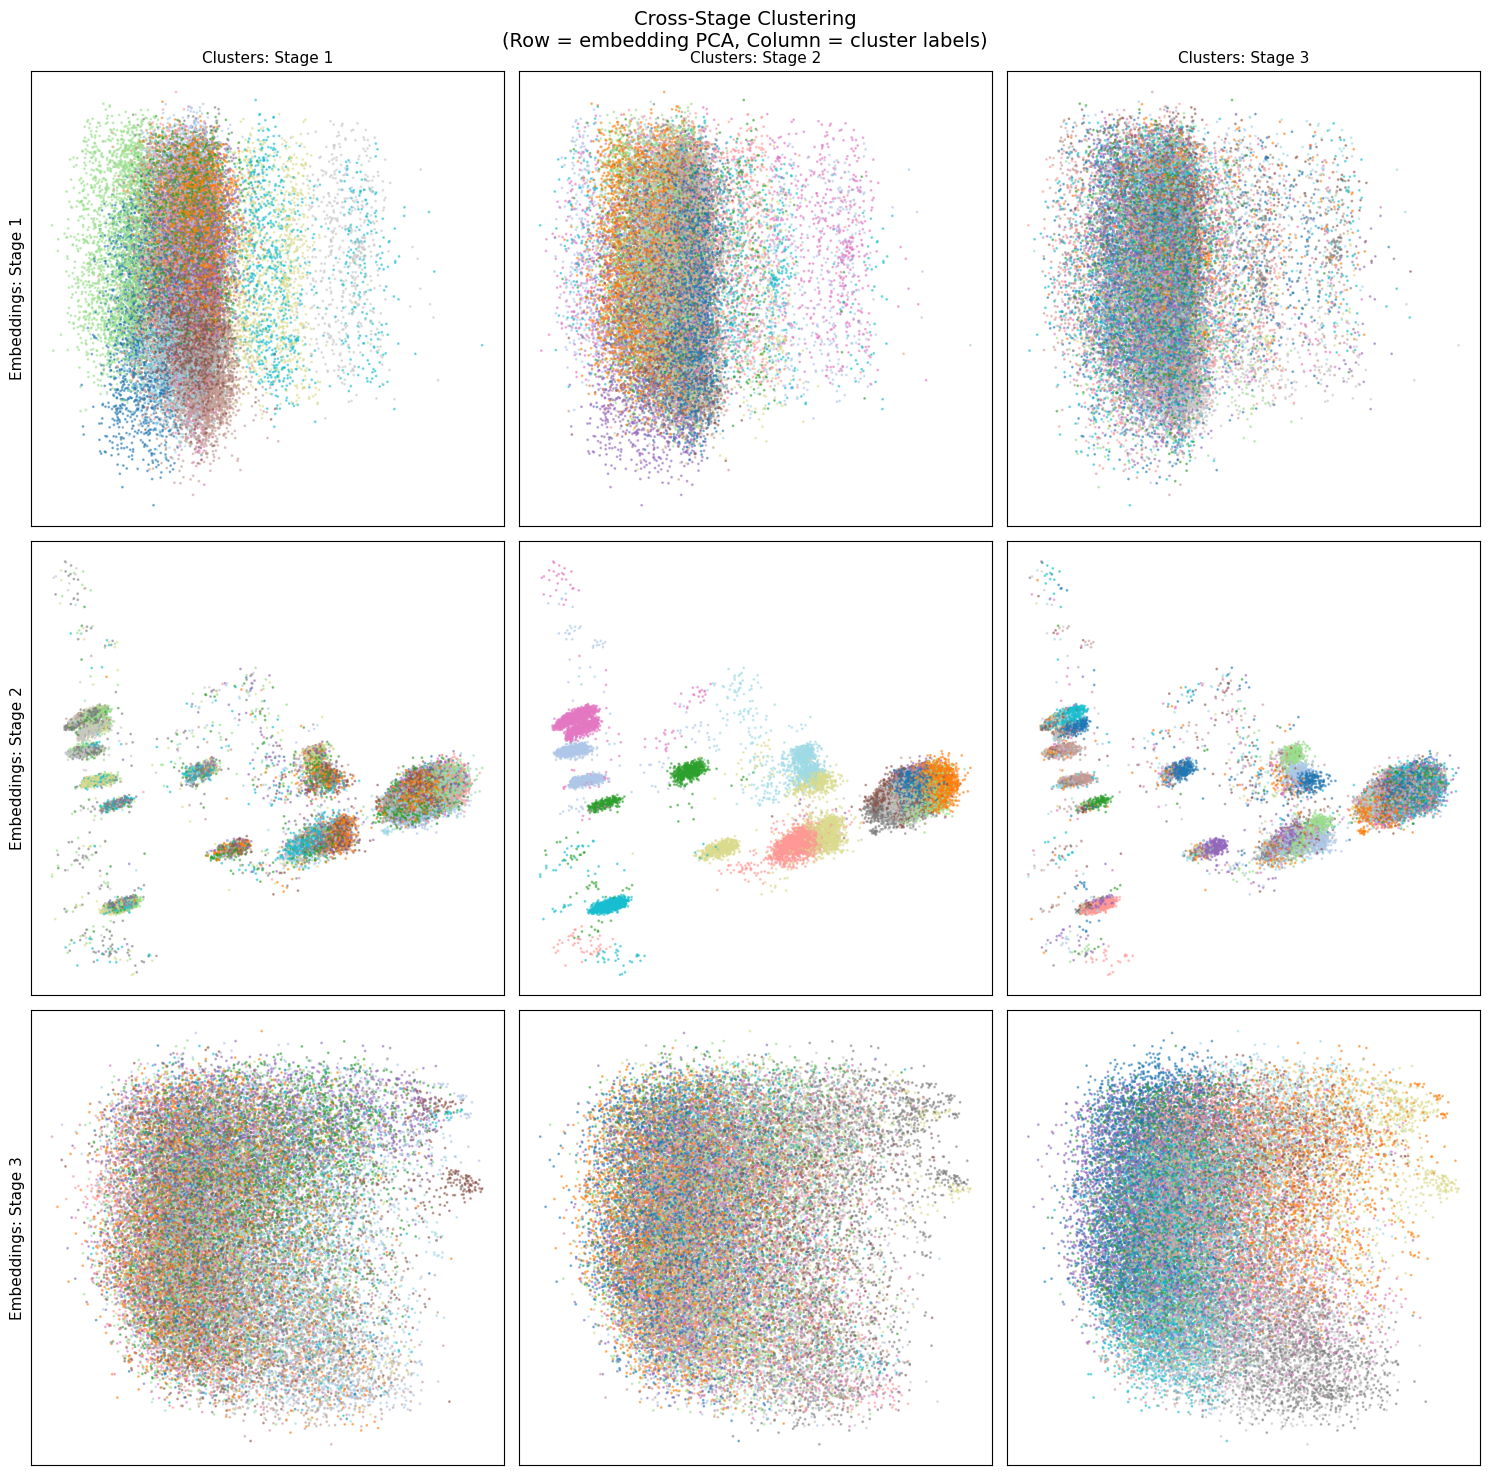

In [13]:
# 3x3 cross-stage clustering visualization
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

stage_names = ["Stage 1", "Stage 2", "Stage 3"]
pca_list = [pca1_result, pca2_result, pca3_result]
labels_list = [labels1_sub, labels2_sub, labels3_sub]  # Use _sub versions

for i, (emb_name, pca_res) in enumerate(zip(stage_names, pca_list)):
    for j, (cluster_name, labels_sub) in enumerate(zip(stage_names, labels_list)):
        ax = axes[i, j]
        scatter = ax.scatter(
            pca_res[cluster_idx, 0], pca_res[cluster_idx, 1],  # Use cluster_idx
            c=labels_sub, cmap='tab20', s=1, alpha=0.5  # labels_sub already correct size
        )
        
        if i == 0:
            ax.set_title(f"Clusters: {cluster_name}", fontsize=11)
        if j == 0:
            ax.set_ylabel(f"Embeddings: {emb_name}", fontsize=11)
        
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle("Cross-Stage Clustering\n(Row = embedding PCA, Column = cluster labels)", fontsize=14)
plt.tight_layout()
plt.show()

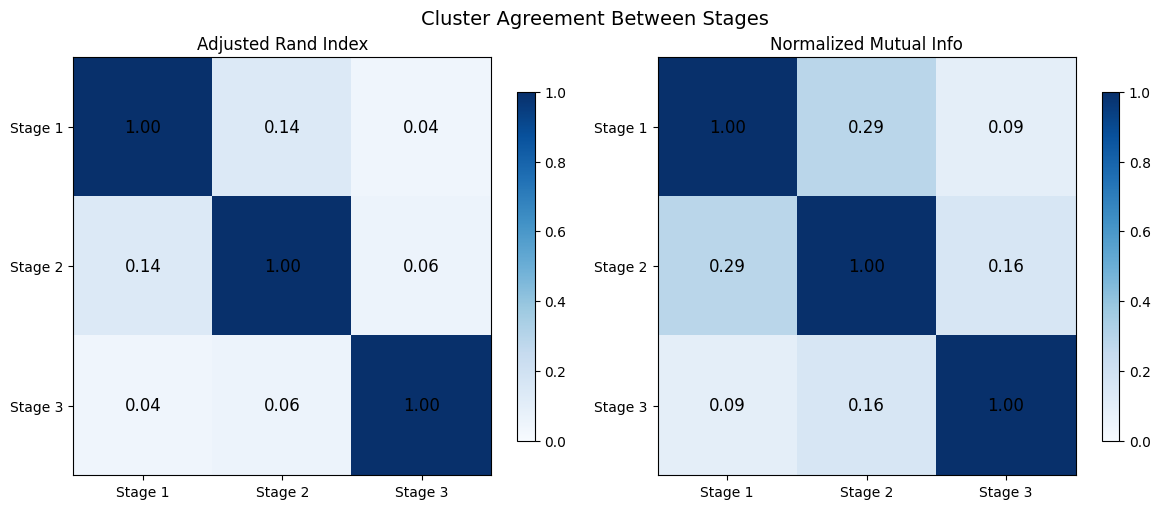

In [16]:
# Cluster agreement matrix between stages
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ARI matrix
ari_matrix = np.zeros((3, 3))
nmi_matrix = np.zeros((3, 3))

labels_list = [labels1_sub, labels2_sub, labels3_sub]  # Make sure this uses _sub

for i, l1 in enumerate(labels_list):
    for j, l2 in enumerate(labels_list):
        ari_matrix[i, j] = adjusted_rand_score(l1, l2)
        nmi_matrix[i, j] = normalized_mutual_info_score(l1, l2)

for ax, matrix, title in zip(axes, [ari_matrix, nmi_matrix], ["Adjusted Rand Index", "Normalized Mutual Info"]):
    im = ax.imshow(matrix, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 1, 2])
    ax.set_xticklabels(stage_names)
    ax.set_yticklabels(stage_names)
    ax.set_title(title)
    
    for ii in range(3):
        for jj in range(3):
            ax.text(jj, ii, f"{matrix[ii, jj]:.2f}", ha='center', va='center', fontsize=12)
    
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle("Cluster Agreement Between Stages", fontsize=14)
plt.tight_layout()
plt.show()

## 7. UMAP Per Stage

In [17]:
if HAS_UMAP:
    # Subsample more aggressively for UMAP
    umap_subsample = 50
    umap_idx = np.arange(0, stage1.shape[0], umap_subsample)
    print(f"Running UMAP on {len(umap_idx)} samples per stage...")
    
    umap1 = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    umap2 = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    umap3 = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    
    umap1_result = umap1.fit_transform(stage1_scaled[umap_idx])
    umap2_result = umap2.fit_transform(stage2_scaled[umap_idx])
    umap3_result = umap3.fit_transform(stage3_scaled[umap_idx])
    
    umap_results = [umap1_result, umap2_result, umap3_result]
    print("UMAP done.")
else:
    print("Skipping UMAP")

Running UMAP on 66129 samples per stage...


/scratch/michal/projects/dvc_ofd_2025/code/BehaveMAE_reconstruction/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/scratch/michal/projects/dvc_ofd_2025/code/BehaveMAE_reconstruction/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/scratch/michal/projects/dvc_ofd_2025/code/BehaveMAE_reconstruction/.venv/lib/python3.9/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/scratch/michal/projects/dvc_ofd_2025/code/BehaveMAE_reconstruction/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done.


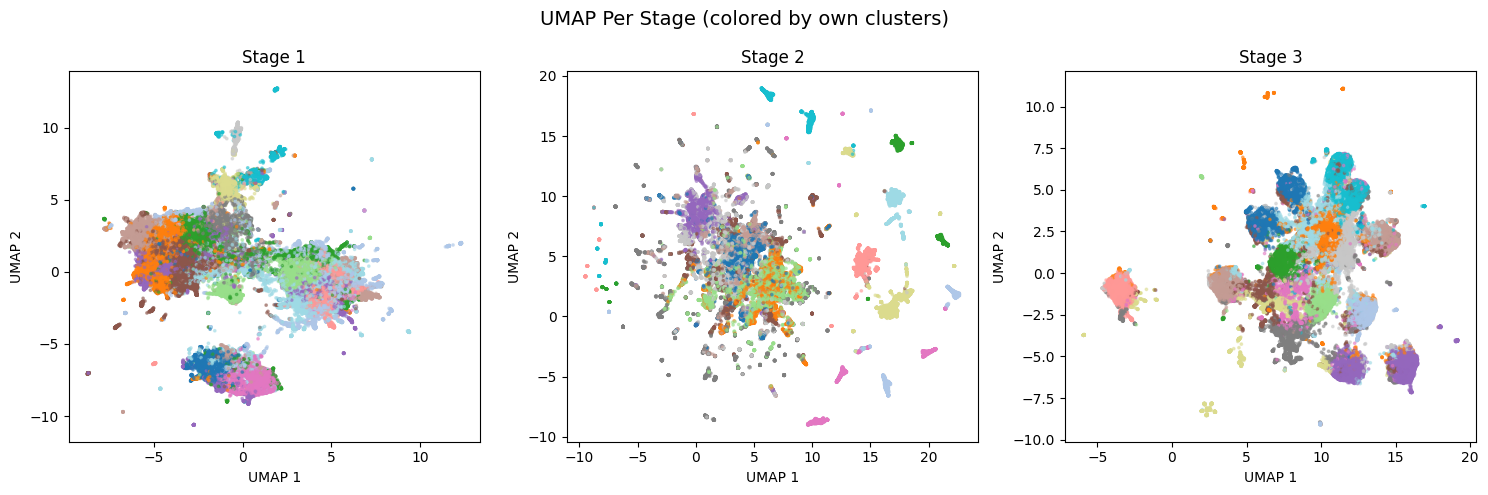

In [20]:
if HAS_UMAP:
    # Get labels for UMAP subsample
    labels1_umap = kmeans1.predict(stage1_scaled[umap_idx])
    labels2_umap = kmeans2.predict(stage2_scaled[umap_idx])
    labels3_umap = kmeans3.predict(stage3_scaled[umap_idx])
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for ax, name, umap_res, labels_umap in zip(axes, stage_names, umap_results, [labels1_umap, labels2_umap, labels3_umap]):
        scatter = ax.scatter(
            umap_res[:, 0], umap_res[:, 1],
            c=labels_umap, cmap='tab20', s=3, alpha=0.5
        )
        ax.set_xlabel("UMAP 1")
        ax.set_ylabel("UMAP 2")
        ax.set_title(f"{name}")
    
    plt.suptitle("UMAP Per Stage (colored by own clusters)", fontsize=14)
    plt.tight_layout()
    plt.show()

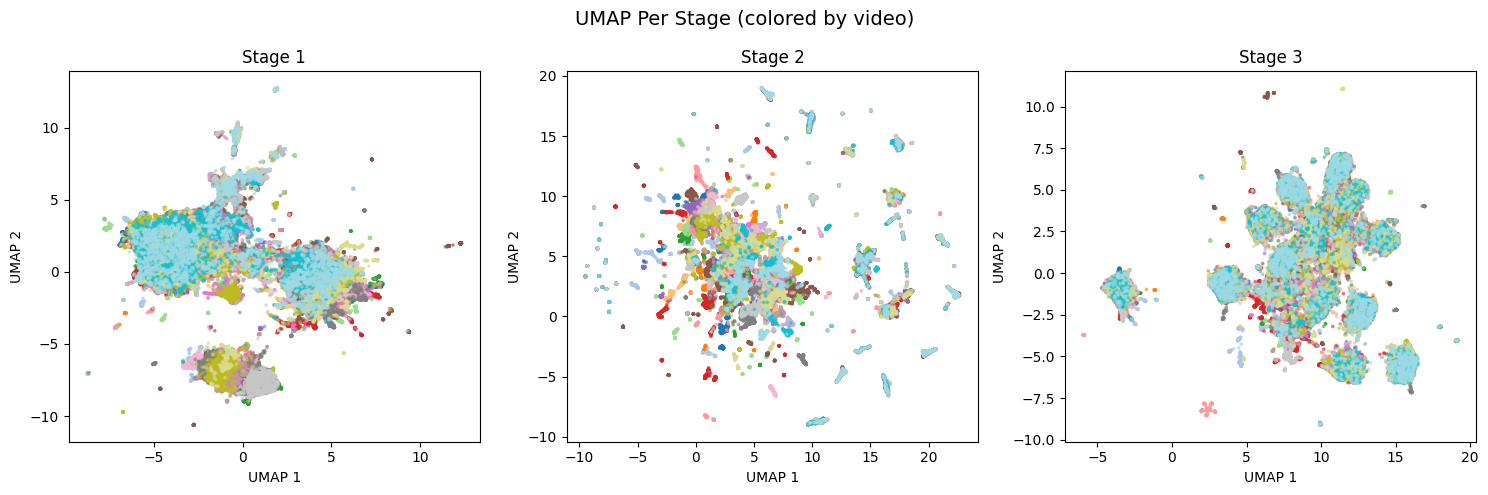

In [21]:
if HAS_UMAP:
    # UMAP colored by video
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for ax, name, umap_res in zip(axes, stage_names, umap_results):
        scatter = ax.scatter(
            umap_res[:, 0], umap_res[:, 1],
            c=video_ids[umap_idx], cmap='tab20', s=3, alpha=0.5
        )
        ax.set_xlabel("UMAP 1")
        ax.set_ylabel("UMAP 2")
        ax.set_title(f"{name}")
    
    plt.suptitle("UMAP Per Stage (colored by video)", fontsize=14)
    plt.tight_layout()
    plt.show()

## 8. Temporal Dynamics Per Stage

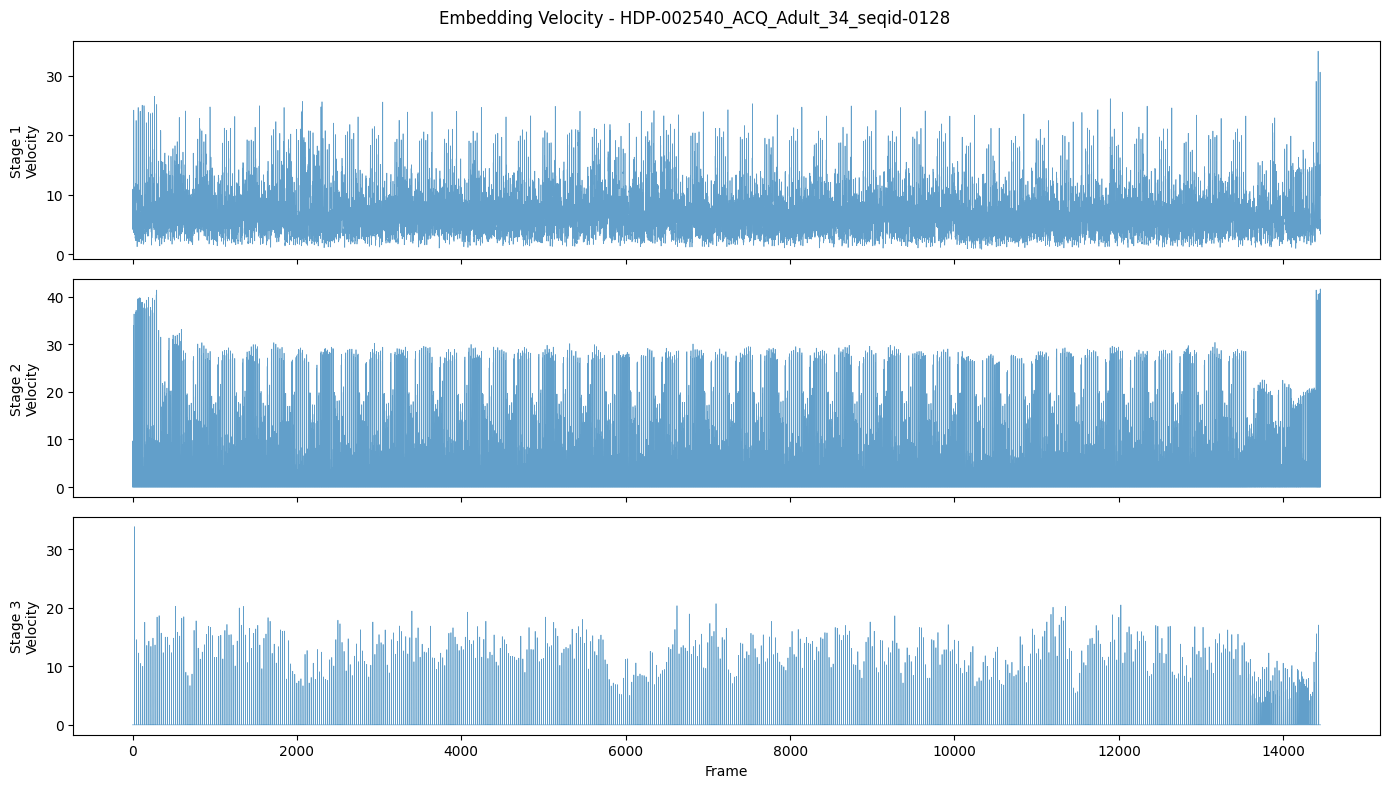

In [22]:
# Embedding velocity per stage (for first video)
vid_idx = 0
start, end = video_boundaries[vid_idx], video_boundaries[vid_idx + 1]

vel1 = np.linalg.norm(np.diff(stage1_scaled[start:end], axis=0), axis=1)
vel2 = np.linalg.norm(np.diff(stage2_scaled[start:end], axis=0), axis=1)
vel3 = np.linalg.norm(np.diff(stage3_scaled[start:end], axis=0), axis=1)

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

for ax, name, vel in zip(axes, stage_names, [vel1, vel2, vel3]):
    ax.plot(vel, linewidth=0.5, alpha=0.7)
    ax.set_ylabel(f"{name}\nVelocity")

axes[-1].set_xlabel("Frame")
plt.suptitle(f"Embedding Velocity - {video_names[vid_idx]}", fontsize=12)
plt.tight_layout()
plt.show()

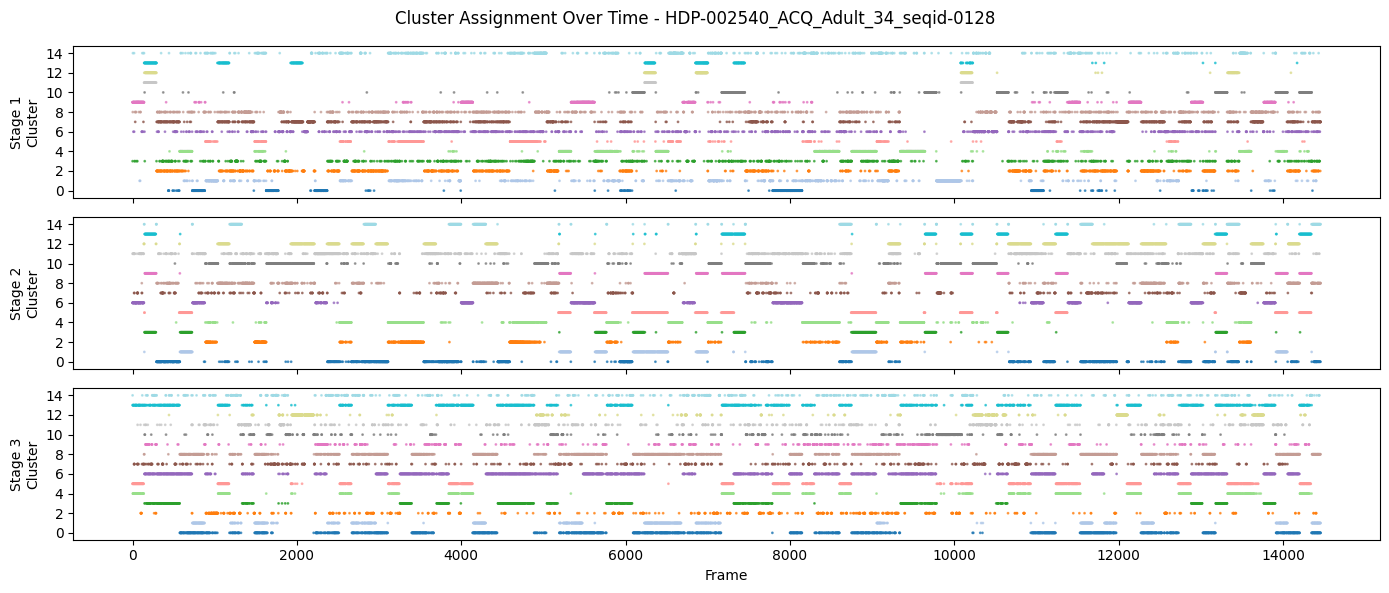

In [23]:
# Cluster transitions over time (first video)
fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)

for ax, name, labels in zip(axes, stage_names, labels_list):
    ax.scatter(
        range(end - start), labels[start:end],
        c=labels[start:end], cmap='tab20', s=1, alpha=0.7
    )
    ax.set_ylabel(f"{name}\nCluster")
    ax.set_yticks(range(0, n_clusters, 2))

axes[-1].set_xlabel("Frame")
plt.suptitle(f"Cluster Assignment Over Time - {video_names[vid_idx]}", fontsize=12)
plt.tight_layout()
plt.show()

## 9. Elbow Method Per Stage

In [ ]:
# Elbow method for each stage
K_range = range(2, 26)

# Subsample for speed
elbow_subsample = 20
elbow_idx = np.arange(0, stage1.shape[0], elbow_subsample)

inertias = {name: [] for name in stage_names}

for k in K_range:
    for name, emb in zip(stage_names, [stage1_scaled, stage2_scaled, stage3_scaled]):
        km = KMeans(n_clusters=k, random_state=42, n_init=5)
        km.fit(emb[elbow_idx])
        inertias[name].append(km.inertia_)
    print(f"k={k} done")

fig, ax = plt.subplots(figsize=(10, 6))
for name in stage_names:
    ax.plot(K_range, inertias[name], marker='o', markersize=4, label=name)

ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Inertia")
ax.set_title("Elbow Method Per Stage")
ax.legend()
plt.tight_layout()
plt.show()